Clasificación espectral II
==

Alumno
---
Pedro G. Villegas

Docentes
---
J.P. Calderón & R. Gamen

Resumen
---
La forma más sencilla de comenzar a estudiar un conjunto de objetos es clasificarlos en función de características comunes, es decir, elaborar su taxonomía. La forma de clasificar a las estrellas se basa en las características de sus espectros, por lo que la llamamos "clasificación espectral". La clasificación espectral divide las estrellas en tipos espectrales y, con un refinamiento posterior, en clases de luminosidad. No obstante, en muchas ocasiones hablamos de tipo espectral para referirnos a la combinación de ambos, el tipo espectral y la clase de luminosidad.

En esta práctica vamos a clasificar una serie de espectros estelares digitales comparando con los estándares provistos en el [“Spectral Classification Atlas”](http://ned.ipac.caltech.edu/level5/Gray/frames.html) de R.O. Gray.

Referencias
---
* [Práctica 06 (overleaf)](https://www.overleaf.com/read/qsjbtpsqtknt)

---

Ejercicios
---
Objetivos:
* Identificar las líneas espectrales presentes en al menos 3 espectros. Para esto, utilize los criterios provistos
por el atlas digital y clasifique cada espectro.

In [1]:
#pip install lineid_plot

In [2]:
#!conda install -c conda-forge specutils

**1.** Cargamos los espectros

In [3]:
import glob
list = sorted ( glob.glob('*.fits') )

In [4]:
list

['espectro001.fits',
 'espectro002.fits',
 'espectro003.fits',
 'espectro004.fits',
 'espectro005.fits',
 'espectro006.fits',
 'espectro007.fits',
 'espectro008.fits',
 'espectro009.fits',
 'espectro010.fits']

In [5]:
from specutils import Spectrum1D

spec = [ 'None' ] * len(list) # Se crea una _lista_ vacia de 10 elementos.
for i, filename in enumerate(list):
    print (i, filename)
    spec[i] = Spectrum1D.read ( filename )

0 espectro001.fits
1 espectro002.fits
2 espectro003.fits
3 espectro004.fits
4 espectro005.fits
5 espectro006.fits
6 espectro007.fits
7 espectro008.fits
8 espectro009.fits
9 espectro010.fits


In [6]:
print ( spec[0] )

Spectrum1D (length=1024)
flux:             [ 0.6776, ..., 0.6933 ],  mean=0.65902
spectral axis:    [ 3810.8 pix, ..., 4630.0 pix ],  mean=4220.4 pix


In [7]:
#!ls -l *fits

In [8]:
spec[0].meta

{'header': SIMPLE  =                    T / Fits standard                                  
 BITPIX  =                  -32 / Bits per pixel                                 
 NAXIS   =                    1 / Number of axes                                 
 NAXIS1  =                 1024 / Axis length                                    
 EXTEND  =                    F / File may contain extensions                    
 ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
 DATE    = '2016-10-19T12:57:49' / Date FITS file was generated                  
 IRAF-TLM= '2016-10-19T13:11:00' / Time of last modification                     
 CRPIX1  =                   1.                                                  
 CRVAL1  =              3810.77                                                  
 CTYPE1  = 'LINEAR  '                                                            
 CD1_1   =            0.8008404                                                  
      

**2.** Graficamos un espectro

<IPython.core.display.Javascript object>


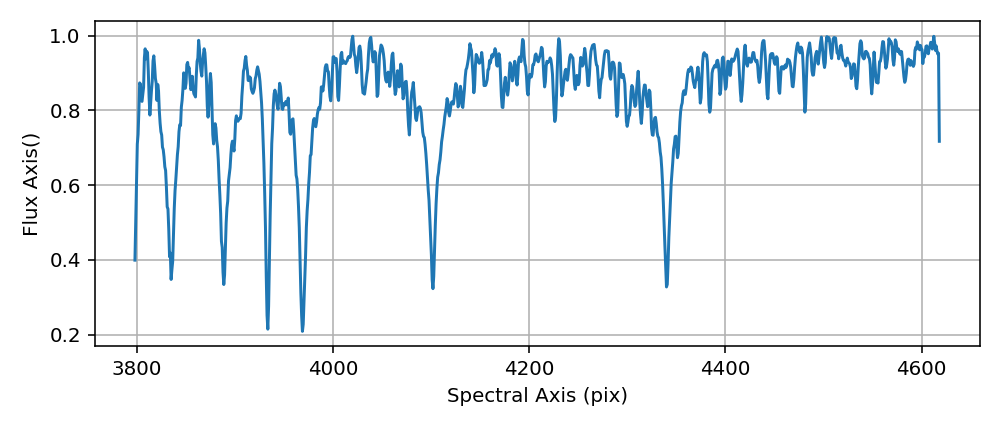

In [18]:
%matplotlib notebook
from matplotlib import pyplot as plt
import lineid_plot

spectrum = spec[3]

fig, ax = plt.subplots( figsize = (7, 3), dpi = 130 )

ax.plot ( spectrum.spectral_axis, spectrum.flux ) 

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

ax.grid ( True ) 
fig.tight_layout()
plt.show()

**3.** Ajustamos una línea particular

In [10]:
from astropy.modeling import models, fitting
from astropy import units as u

region = [ 4300, 4380 ] * u.AA
mask = ( spectrum.spectral_axis.value * u.AA >= region[0] ) & ( spectrum.spectral_axis.value * u.AA <= region[1] )  

x = spectrum.spectral_axis [ mask ] 
y = spectrum.flux [ mask ]

bg = models.Const1D ( amplitude = 1 )
gs = models.Gaussian1D ( amplitude = 1, mean = 4340, stddev = 5 )

init_model = bg - gs
fitter = fitting.LevMarLSQFitter()
fit_model = fitter ( init_model, spectrum.spectral_axis, spectrum.flux )  

y_fit = fit_model ( x )  

print ( fit_model )  

Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] - [1]
Components: 
    [0]: <Const1D(amplitude=0.85732689 )>

    [1]: <Gaussian1D(amplitude=0.41298636 , mean=4340.32858206 pix, stddev=6.07077942 pix)>
Parameters:
       amplitude_0        amplitude_1           mean_1           stddev_1    
                                                 pix               pix       
    ------------------ ------------------ ----------------- -----------------
    0.8573268929810569 0.4129863632933791 4340.328582063008 6.070779421054505


<IPython.core.display.Javascript object>


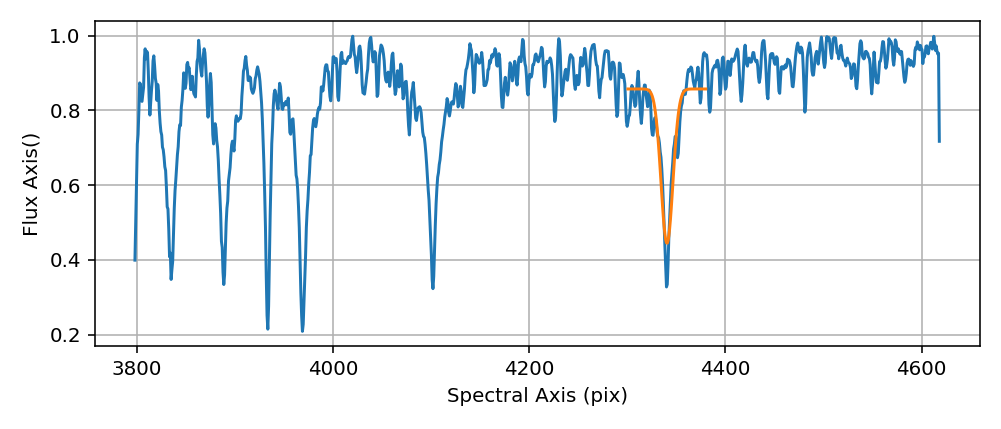

In [19]:
%matplotlib notebook
from matplotlib import pyplot as plt

fig, ax = plt.subplots( figsize = (7,3), dpi = 130 )

ax.plot ( spectrum.spectral_axis, spectrum.flux) 
ax.plot ( x, y_fit )

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

ax.grid ( True ) 
fig.tight_layout()
plt.show()

¿Puede identificar líneas que estén presentes en los 10 espectros?

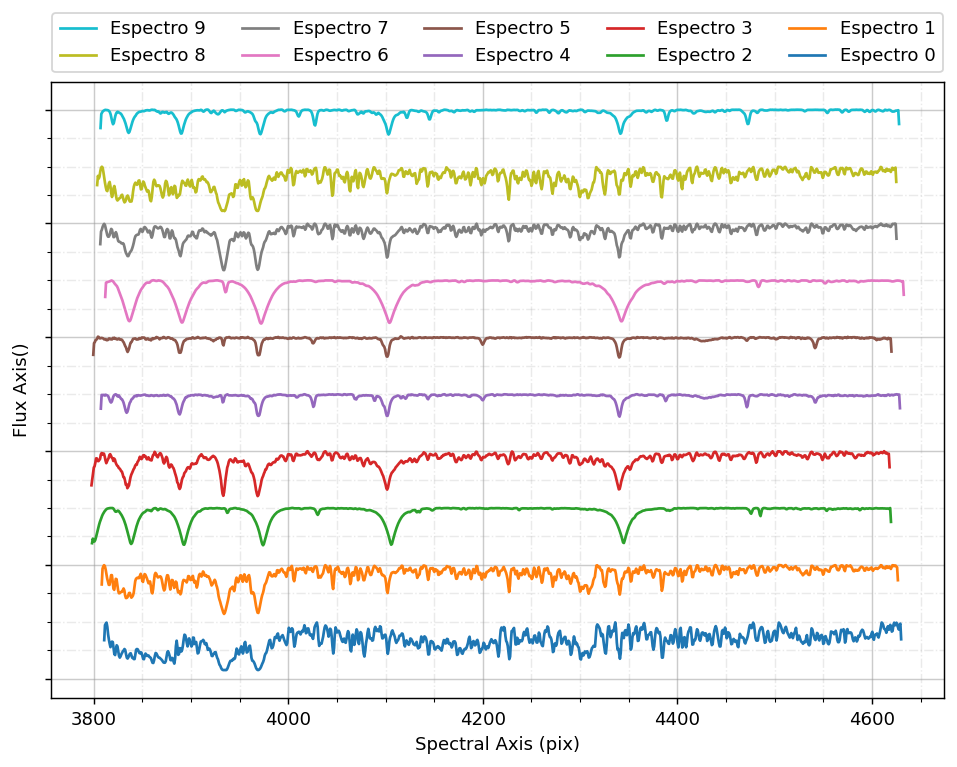

In [37]:
%matplotlib inline
from matplotlib import pyplot as plt

fig, ax = plt.subplots( figsize = (7.9, 6), dpi = 130 )

for i in range(0, 10):
    ax.plot ( spec[i].spectral_axis, spec[i].flux + i, label = "Espectro %i" % (i) ) 

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

# Show the major grid lines with dark grey lines
plt.grid ( b = True, which = 'major', color = '#999999', linestyle ='-', alpha = 0.5 )

# Show the minor grid lines with very faint and almost transparent grey lines
plt.minorticks_on()
plt.grid ( b = True, which = 'minor', color = '#999999', linestyle = '-.', alpha = 0.2 )
ax.set_yticklabels([])

# Invierte el orden en el que muestra la legenda
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc = "lower center", bbox_to_anchor = (0.5, 1.0), ncol = 5 )

fig.tight_layout()
plt.show()

In [13]:
# Lineas presentes en todos los espectros:
#3970 AA
#4100 AA
#4340 AA

# Elijo los espectros gris (7), naranja (1) y azul (0)

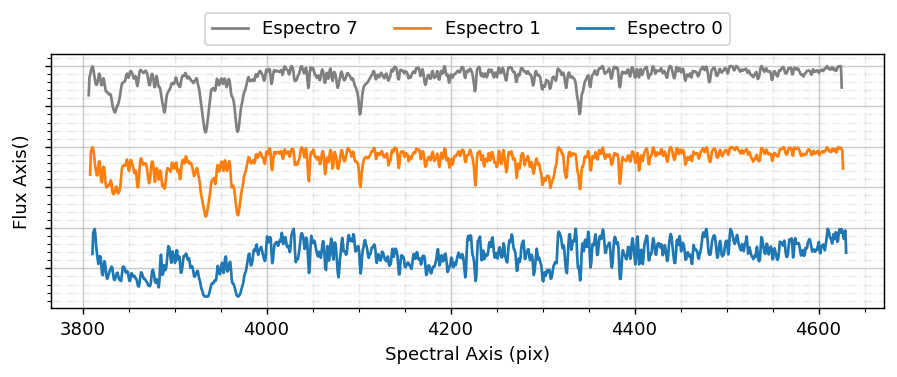

In [39]:
%matplotlib inline
from matplotlib import pyplot as plt

fig, ax = plt.subplots( figsize = (7, 3), dpi = 130 )

ax.plot ( spec[0].spectral_axis, spec[0].flux + 0, label = "Espectro 0" ) 
ax.plot ( spec[1].spectral_axis, spec[1].flux + 1, label = "Espectro 1" ) 
ax.plot ( spec[7].spectral_axis, spec[7].flux + 2, label = "Espectro 7", color = 'gray' ) 

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

# Show the major grid lines with dark grey lines
plt.grid ( b = True, which = 'major', color = '#999999', linestyle ='-', alpha = 0.5 )

# Show the minor grid lines with very faint and almost transparent grey lines
plt.minorticks_on()
plt.grid ( b = True, which = 'minor', color = '#999999', linestyle = '-.', alpha = 0.2 )
ax.set_yticklabels([])

# Invierte el orden en el que muestra la legenda
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc = "lower center", bbox_to_anchor = (0.5, 1.0), ncol = 5 )

fig.tight_layout()
plt.show()

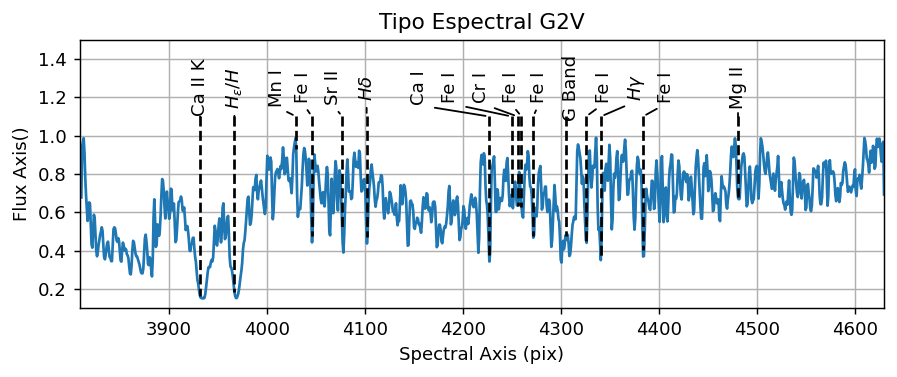

In [77]:
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import lineid_plot

n = 0
spectrum = spec[n]

fig, ax = plt.subplots( figsize = (7, 3), dpi = 130 )

#line_wave = [ 4030, 4227, 4271, 4471, 4481 ]
#line_label = [ 'Mn I', 'Ca I', 'Fe I', 'He I', 'Mg II' ]

line_wave =  [      3932,               3967,   4030,   4046,    4077,        4102,   4227,   4250,   4256,   4260,   4272,     4305,   4326,       4341,   4384,    4481 ]
line_label = [ 'Ca II K', '$H_{\epsilon}/H$', 'Mn I', 'Fe I', 'Sr II', '$H\delta$', 'Ca I', 'Fe I', 'Cr I', 'Fe I', 'Fe I', 'G Band', 'Fe I','$H\gamma$', 'Fe I', 'Mg II' ] # Líneas típicas de una estrella tipo A


ax.plot ( spectrum.spectral_axis, spectrum.flux ) 
lineid_plot.plot_line_ids ( spectrum.spectral_axis, spectrum.flux, 
                           line_wave, line_label, 
                           arrow_tip = 1.1, box_loc = 1.25, ax = ax )

ax.set_title ( 'Tipo Espectral G2V' )
ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

a = ax.findobj(mpl.text.Annotation)
for i in a:
    i.set_fontsize(10)
    
ax.set_ylim ( 0.1, 1.5 )
ax.set_xlim ( 3809, 4630 )
ax.grid ( True ) 
fig.tight_layout()
plt.show()

# Qué pasa con las líneas H9 y H8 que se unen en un bodoque?
# Espectro similar al de una G0v - G5V

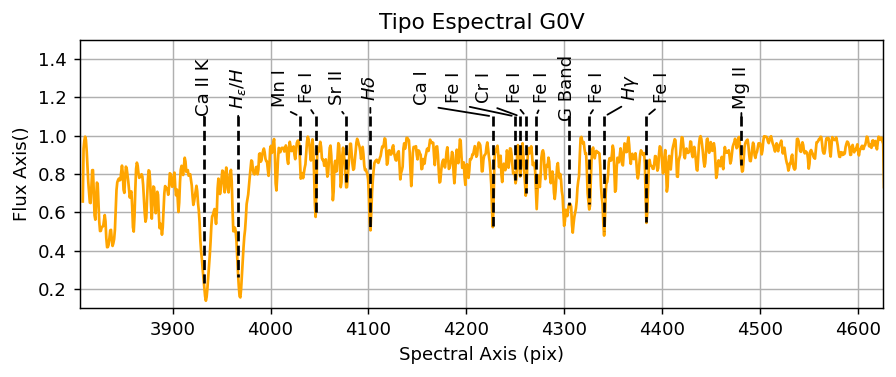

In [71]:
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import lineid_plot

n = 1
spectrum = spec[n]

fig, ax = plt.subplots( figsize = (7, 3), dpi = 130 )

line_wave =  [      3932,               3967,   4030,   4046,    4077,        4102,   4227,   4250,   4255,   4261,   4271,     4305,   4325,       4341,   4384,    4481 ]
line_label = [ 'Ca II K', '$H_{\epsilon}/H$', 'Mn I', 'Fe I', 'Sr II', '$H\delta$', 'Ca I', 'Fe I', 'Cr I', 'Fe I', 'Fe I', 'G Band', 'Fe I','$H\gamma$', 'Fe I', 'Mg II' ] # Líneas típicas de una estrella tipo A

ax.plot ( spectrum.spectral_axis, spectrum.flux, color = 'orange' ) 
lineid_plot.plot_line_ids ( spectrum.spectral_axis, spectrum.flux, 
                           line_wave, line_label, 
                           arrow_tip = 1.1, box_loc = 1.25, ax = ax )

ax.set_title ( 'Tipo Espectral G0V' )
ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

a = ax.findobj(mpl.text.Annotation)
for i in a:
    i.set_fontsize(10)
    
ax.set_ylim ( 0.1, 1.5 )
ax.set_xlim ( 3805, 4626 )
ax.grid ( True ) 
fig.tight_layout()
plt.show()

#Será una G0V? -----> Banda G muy parecida a la línea Fe 4383, línea H9 Ancha y difusa

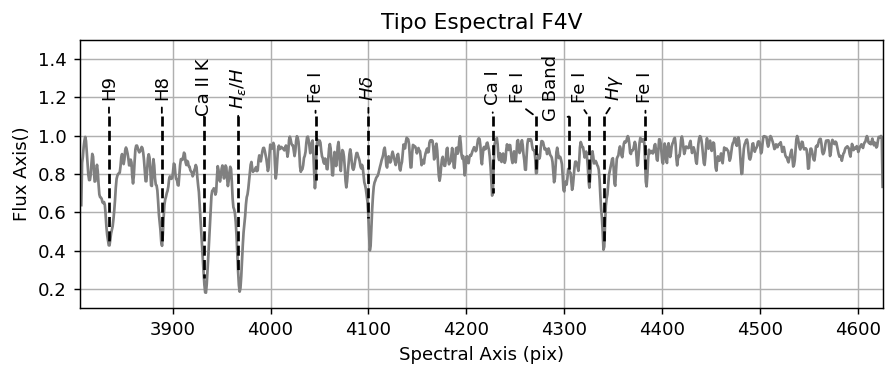

In [49]:
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import lineid_plot

n = 7
spectrum = spec[n]

fig, ax = plt.subplots( figsize = (7, 3), dpi = 130 )

#line_wave = [ 4030, 4227, 4271, 4471, 4481 ]
#line_label = [ 'Mn I', 'Ca I', 'Fe I', 'He I', 'Mg II' ]

line_wave = [  3835, 3889,      3932,               3967,   4046,        4100,   4227,   4271,     4305,   4325,       4341,   4383 ]
line_label = [ 'H9', 'H8', 'Ca II K', '$H_{\epsilon}/H$', 'Fe I', '$H\delta$', 'Ca I', 'Fe I', 'G Band', 'Fe I','$H\gamma$', 'Fe I' ] # Líneas típicas de una estrella tipo F


ax.plot ( spectrum.spectral_axis, spectrum.flux, color = 'gray' ) 
lineid_plot.plot_line_ids ( spectrum.spectral_axis, spectrum.flux, 
                           line_wave, line_label, 
                           arrow_tip = 1.1, box_loc = 1.25, ax = ax )

ax.set_title ( 'Tipo Espectral F4V' )#'FITS file with 1D: ' + str(list[n]) )
ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

a = ax.findobj(mpl.text.Annotation)
for i in a:
    i.set_fontsize(10)
    
ax.set_ylim ( 0.1, 1.5 )
ax.set_xlim ( 3805, 4626 )
ax.grid ( True ) 
fig.tight_layout()
plt.show()

# Líneas H9 y H8 bien definidas, espectro entre una F2V o una F5V